# Kuramoto Dynamics — Meteorology, Topology, and Cosmic Web Analogues

Six simulations sharing a common mathematical substrate: the Kuramoto coupled-oscillator model.
(Cells 4 and 5 are two variants of the same Hebbian experiment.)

| Cell | System | Claim |
|------|--------|-------|
| 0 | 2D torus (35×35) | Spatial frequency anomaly (toy, not blocking) |
| 1 | Barabási–Albert graph | Attention-topology: scale-free network + lock-drift boundary |
| 2 | 1D ring, sinusoidal ω | Spacetime coarsening — visual resemblance to caustic merging |
| 3 | Robustness check | Same as cell 2 with Gaussian ω — tests load-bearing of claim |
| 4 | Hebbian Kuramoto | Does Hebbian rewiring produce scale-free topology? (negative result) |
| 5 | Conserved Hebbian | Same with connection-budget conservation law |

**Fold condition used throughout:** The lock-drift threshold `K·R_eff = |Δ|` is a saddle-node
*indicator* adapted from Kuramoto (1984) and Strogatz et al. (1992). Exact for global
mean-field; local heuristic for NN/graph coupling. Read as a diagnostic level set, not
a sharp boundary.

**R_eff normalisation varies by cell:**
- Cell 0: R_eff ∈ [0,4] (4 nearest neighbours, unnormalised)
- Cell 1: R_eff ∈ [0,1] (row-normalised W)
- Cells 2–3: R_eff ∈ [0,2] (2 nearest neighbours on a 1D ring)

The fold condition K·R_eff = |Δ| has different physical scales in each cell.

**Ω convention varies by cell:** Long-time average in Cell 0; conserved mean(ω) in
Cells 2–3 (coupling terms telescope to zero on a periodic ring); instantaneous
mean(dθ/dt) in Cells 1, 4, 5.


## Cell 0 — 2D Kuramoto Torus: Spatial Frequency Anomaly (Not Atmospheric Blocking)

A 35×35 grid of coupled oscillators on a periodic (toroidal) 2D lattice.
Rows 10–14 (omega[10:15] in Python = rows 10 through 14) receive a +1.0 frequency boost as a toy anomaly.

**What to look for:** The lock-drift contour (cyan) marks where the local coupling
field `K·R_eff` equals the local detuning `|ω_i − Ω|`. Oscillators inside the cyan
boundary are drifting; those outside are locally locked. The frequency-boosted jet
rows should show persistent drifting structure.

**Caveat:** This is a very crude meteorological analogy. The atmosphere is not a
Kuramoto ring. Also note: T=50 is only ~3.7% of the diffusion timescale (τ ≈ L²/K ≈ 1361).
This is not a model of atmospheric blocking. There is no advection, geostrophic balance,
vorticity, or beta-plane structure. It is a toy showing how a frequency anomaly produces
reduced local coherence and threshold crossings. T=50 is a transient, not quasi-stationary.


Integrating toy 2D Kuramoto torus...
Omega (time-averaged): 0.128393
fold_residual: min=-0.750907, max=3.583195


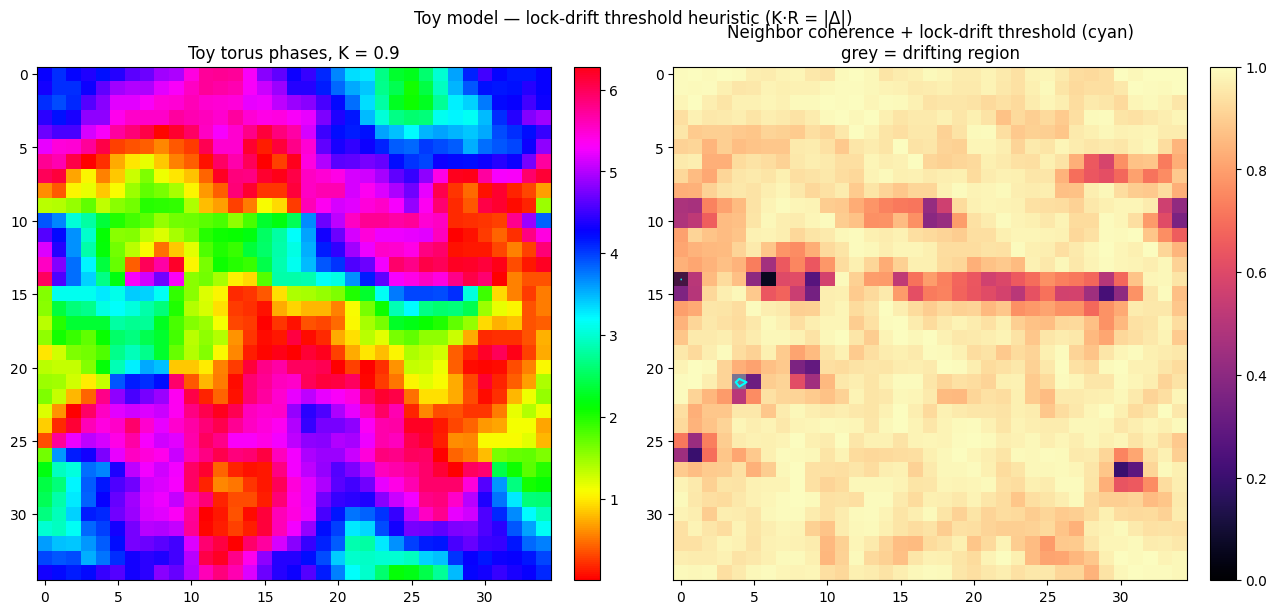

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

L = 35
N = L * L
K = 0.9

rng = np.random.default_rng(42)
omega = rng.normal(0.0, 0.5, (L, L))
omega[10:15, :] += 1.0

def kuramoto_2d(t, theta_flat):
    theta = theta_flat.reshape((L, L))
    coupling = (
        np.sin(np.roll(theta, 1, axis=0) - theta)
        + np.sin(np.roll(theta, -1, axis=0) - theta)
        + np.sin(np.roll(theta, 1, axis=1) - theta)
        + np.sin(np.roll(theta, -1, axis=1) - theta)
    )
    return (omega + K * coupling).ravel()

def compute_neighbor_field(theta):
    z = np.exp(1j * theta)
    Z_eff = (
        np.roll(z, 1, axis=0) + np.roll(z, -1, axis=0)
        + np.roll(z, 1, axis=1) + np.roll(z, -1, axis=1)
    )
    return np.abs(Z_eff)

theta0 = rng.uniform(0, 2 * np.pi, N)
T = 50
print("Integrating toy 2D Kuramoto torus...")
sol = solve_ivp(kuramoto_2d, [0, T], theta0, method="RK45",
                t_eval=np.linspace(0, T, 500))
if not sol.success:
    raise RuntimeError(f"Integration failed: {sol.message}")

theta_final = sol.y[:, -1].reshape((L, L))
R_eff = compute_neighbor_field(theta_final)

# Time-averaged Omega from final 10% of integration
idx_start = int(0.9 * sol.t.size)
dt = sol.t[-1] - sol.t[idx_start]
avg_velocities = (sol.y[:, -1] - sol.y[:, idx_start]) / dt
Omega = np.mean(avg_velocities)
Delta = np.abs(omega - Omega)
fold_residual = K * R_eff - Delta
r_neighbor = R_eff / 4.0

print(f"Omega (time-averaged): {Omega:.6f}")
print(f"fold_residual: min={fold_residual.min():.6f}, max={fold_residual.max():.6f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

im1 = ax1.imshow(theta_final % (2 * np.pi), cmap="hsv", interpolation="nearest")
ax1.set_title(f"Toy torus phases, K = {K}")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

im2 = ax2.imshow(r_neighbor, cmap="magma", vmin=0, vmax=1)

# Drifting region overlay
drifting_mask = np.ma.masked_where(fold_residual >= 0, fold_residual)
ax2.imshow(drifting_mask, cmap="Greys", alpha=0.5, vmin=-1, vmax=0)

# Lock-drift boundary contour
if np.nanmin(fold_residual) <= 0 <= np.nanmax(fold_residual):
    ax2.contour(fold_residual, levels=[0], colors="cyan", linewidths=1.5)
else:
    print("No K·R = |Δ| crossing in this run.")

ax2.set_title("Neighbor coherence + lock-drift threshold (cyan)\ngrey = drifting region")
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.suptitle("Toy model — lock-drift threshold heuristic (K·R = |Δ|)")
plt.tight_layout()
plt.show()


## Cell 1 — Kuramoto on Attention-Topology Graph (Barabási–Albert)

N=100 oscillators on a scale-free graph (BA model, m=3). Row-normalised adjacency
weights. Natural frequencies inversely proportional to degree: `ω_i ~ N(0,2)/(degree+1)`,
so hub nodes are easier to entrain.

**What to look for:** Locked nodes (circles), drifting nodes (squares), and the
lock-drift boundary (cyan). Note: hubs may lock first partly because omega ~ 1/(degree+1)
makes high-degree nodes easier to entrain by construction. The topology and the
degree-frequency coupling are confounded here.

**Note on the fold condition:** With row-normalised W, R_eff ∈ [0,1]. For low-degree
nodes, `|ω_i|` can be large (std~2), making drifting likely. The margin parameter
(0.05) defines a threshold band around the exact crossing.


Integrating Kuramoto on attention-topology graph...
Omega (time-averaged): -0.013305
fold_residual: min=-0.085879, max=0.740701
Locked: 95, Threshold: 4, Drifting: 1


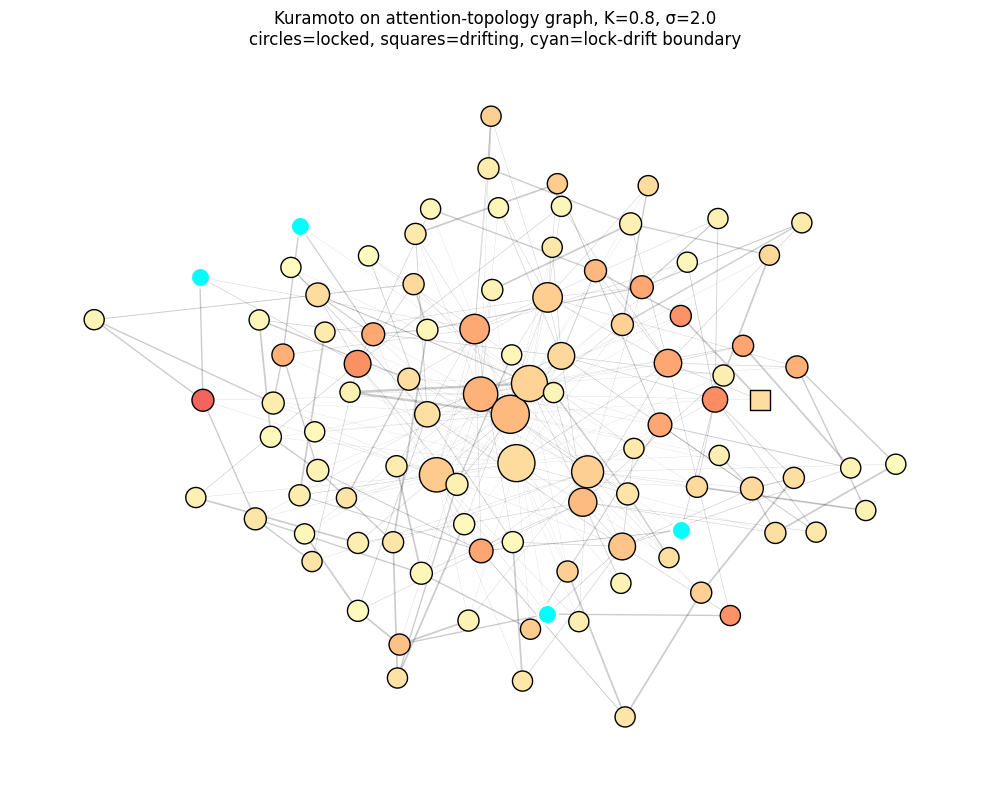

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import networkx as nx

N = 100
K = 0.8

G = nx.barabasi_albert_graph(N, m=3, seed=42)
W = nx.to_numpy_array(G)
row_sums = W.sum(axis=1, keepdims=True)
W = np.divide(W, row_sums, out=np.zeros_like(W), where=row_sums > 0)
degrees = np.array([d for _, d in G.degree()])

rng = np.random.default_rng(42)
omega = rng.normal(0, 2.0, N) / (degrees + 1)

def kuramoto_attention_topology(t, theta):
    diff_matrix = theta[np.newaxis, :] - theta[:, np.newaxis]
    coupling = np.sum(W * np.sin(diff_matrix), axis=1)
    return omega + K * coupling

theta0 = rng.uniform(0, 2 * np.pi, N)
T = 30
print("Integrating Kuramoto on attention-topology graph...")
sol = solve_ivp(kuramoto_attention_topology, [0, T], theta0, method="RK45",
                t_eval=np.linspace(0, T, 300))
if not sol.success:
    raise RuntimeError(f"Integration failed: {sol.message}")

theta_final = sol.y[:, -1]

z = np.exp(1j * theta_final)
Z = W @ z
R_eff = np.abs(Z)

# Time-averaged Omega from final 10%
idx_start = int(0.9 * sol.t.size)
dt = sol.t[-1] - sol.t[idx_start]
avg_velocities = (sol.y[:, -1] - sol.y[:, idx_start]) / dt
Omega = np.mean(avg_velocities)
Delta = np.abs(omega - Omega)
fold_residual = K * R_eff - Delta

margin = 0.05
locked_nodes = np.where(fold_residual >= margin)[0]
drifting_nodes = np.where(fold_residual <= -margin)[0]
threshold_nodes = np.where(np.abs(fold_residual) < margin)[0]

print(f"Omega (time-averaged): {Omega:.6f}")
print(f"fold_residual: min={fold_residual.min():.6f}, max={fold_residual.max():.6f}")
print(f"Locked: {len(locked_nodes)}, Threshold: {len(threshold_nodes)}, Drifting: {len(drifting_nodes)}")

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=0.3)
edges = G.edges()
weights = [W[u, v] * 5 for u, v in edges]
nx.draw_networkx_edges(G, pos, alpha=0.2, width=weights, ax=ax)

nx.draw_networkx_nodes(G, pos, nodelist=locked_nodes.tolist(),
    node_size=150 + degrees[locked_nodes]*20,
    node_color=R_eff[locked_nodes], cmap="magma",
    vmin=0, vmax=1, edgecolors="black", ax=ax)

nx.draw_networkx_nodes(G, pos, nodelist=drifting_nodes.tolist(),
    node_size=150 + degrees[drifting_nodes]*20,
    node_color=R_eff[drifting_nodes], cmap="magma",
    vmin=0, vmax=1, edgecolors="black", node_shape="s", ax=ax)

if len(threshold_nodes) > 0:
    nx.draw_networkx_nodes(G, pos, nodelist=threshold_nodes.tolist(),
        node_size=200, node_color="cyan",
        edgecolors="white", linewidths=2, ax=ax)

ax.set_title(
    f"Kuramoto on attention-topology graph, K={K}, σ=2.0\n"
    "circles=locked, squares=drifting, cyan=lock-drift boundary"
)
ax.axis("off")
plt.tight_layout()
plt.show()


## Cell 2 — 1D Ring Spacetime Merger Plot: Burgers/Zel'dovich Analogy

**The central result of this notebook.**

N=200 oscillators on a 1D ring with sinusoidal natural frequencies
`ω = 1.5·sin(2x) + 0.5·sin(5x)`. The spacetime plot shows lock-drift boundaries
evolving and merging hierarchically over T=200.

**What this plot shows:** A nearest-neighbour Kuramoto ring with smooth structured
frequency disorder develops coarsening lock-drift domains. The visual analogy to adhesion-model
caustic mergers is suggestive: many small boundaries collapse into fewer larger structures.
The Gaussian control (Cell 3) shows this coarsening is not generic.

This is not a derivation of Burgers or Zel'dovich dynamics. Treat this as a suggestive
geometric resemblance, not a quantitative equivalence. The scalar coarsening diagnostic
below substantiates the visual claim.

**Frequency choice:** Sinusoidal ω produces clean hierarchical merging, most directly
analogous to structured initial conditions in the adhesion model. See Cell 3 for the
Gaussian ω robustness check — chimera-like domains persist but merging is noisier.

**Fold condition:** Saddle-node *indicator*, not a sharp bifurcation boundary (Strogatz & Mirollo 1991). Exact for global mean-field; heuristic for NN coupling.


Integrating 1D Kuramoto ring (N=200, T=200)...
Computing lock-drift boundaries across time...


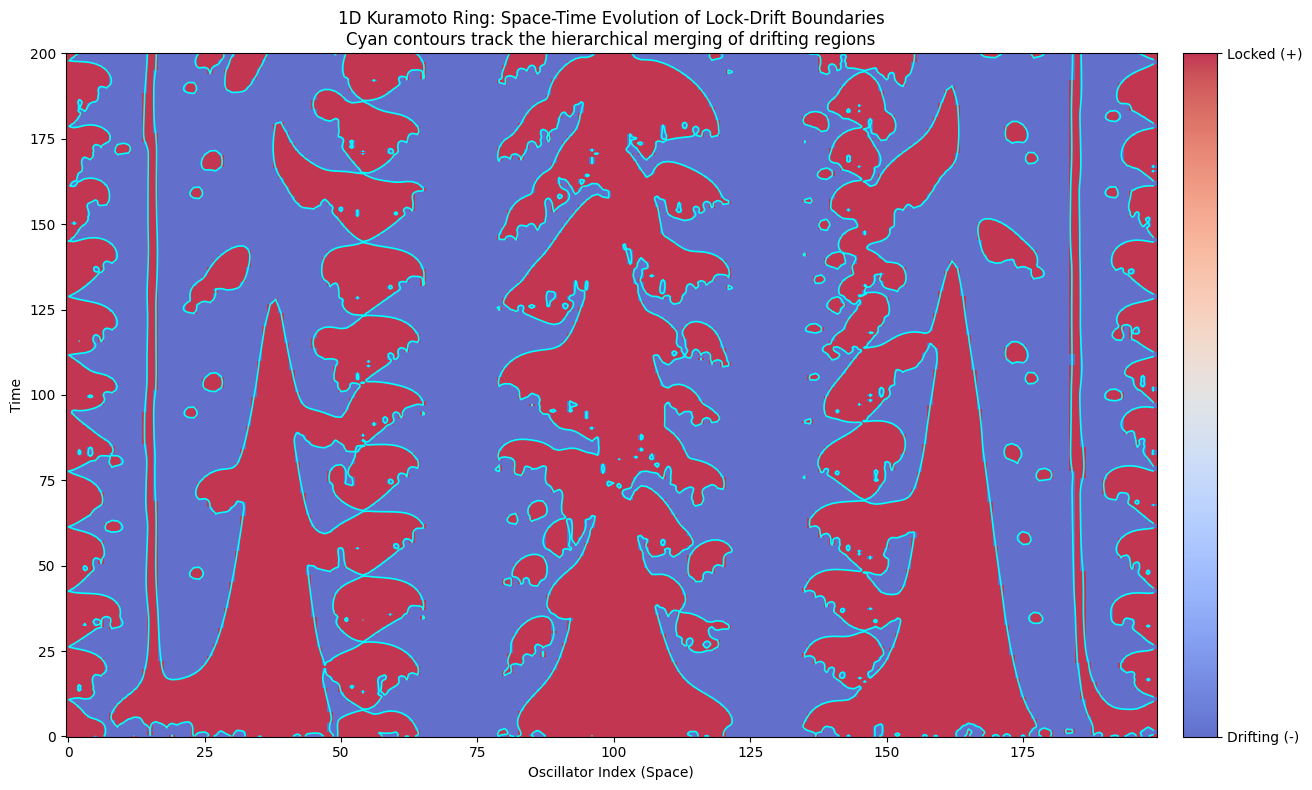

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

N = 200
K = 0.8
T = 200  # sigma variable removed — omega is sinusoidal, not Gaussian
num_steps = 1500  # Dense sampling for high-resolution contours

# 1. Setup Frequencies and Initial Conditions
rng_sp = np.random.default_rng(42)
# Strictly periodic on the discrete ring: x on [0, 2π) with endpoint=False.
# Harmonics 2 and 5 are both integers → both complete whole cycles → no seam discontinuity.
x = np.linspace(0, 2 * np.pi, N, endpoint=False)
omega = 1.5 * np.sin(2 * x) + 0.5 * np.sin(5 * x)
theta0 = rng_sp.uniform(0, 2 * np.pi, N)

# 2. Define 1D Ring Kuramoto Dynamics
def kuramoto_1d(t, theta):
    # Nearest-neighbour coupling with periodic boundary conditions
    theta_left = np.roll(theta, 1)
    theta_right = np.roll(theta, -1)

    coupling = np.sin(theta_left - theta) + np.sin(theta_right - theta)
    return omega + K * coupling

# 3. Integrate
print(f"Integrating 1D Kuramoto ring (N={N}, T={T})...")
t_eval = np.linspace(0, T, num_steps)
sol = solve_ivp(kuramoto_1d, [0, T], theta0, method="DOP853", t_eval=t_eval, rtol=1e-7, atol=1e-9)
# Exact contour morphology is solver-sensitive late in time; coarse boundary-count decline is stable.

if not sol.success:
    raise RuntimeError(f"Integration failed: {sol.message}")

theta_t = sol.y  # Shape: (N, num_steps)

# 4. Compute Space-Time Diagnostics
print("Computing lock-drift boundaries across time...")
fold_residual = np.zeros((N, num_steps))

for j in range(num_steps):
    theta = theta_t[:, j]

    # Local neighborhood coherence
    z = np.exp(1j * theta)
    Z_eff = np.roll(z, 1) + np.roll(z, -1)
    R_eff = np.abs(Z_eff)

    # On a periodic 1D ring, coupling terms telescope to zero so mean(dθ/dt) = mean(ω) exactly.
    # Omega_t is a conserved quantity here (std < 1e-10 over the run).
    # NOTE: this conservation does NOT hold in Cells 0, 1, 4, 5 — those have non-trivial network structure.
    dtheta = kuramoto_1d(sol.t[j], theta)
    Omega_t = np.mean(dtheta)

    # Threshold calculation
    Delta = np.abs(omega - Omega_t)
    fold_residual[:, j] = K * R_eff - Delta

# 5. Plotting
fig, ax = plt.subplots(figsize=(14, 8))

# Meshgrid for space-time axes
X, Y = np.meshgrid(np.arange(N), sol.t)

# Heatmap: +1 = Locked (Red), -1 = Drifting (Blue)
# We transpose fold_residual to match (time, space) axes for pcolormesh
Z = np.sign(fold_residual.T)
im = ax.pcolormesh(X, Y, Z, cmap="coolwarm", shading="nearest", alpha=0.8)

# Overlay cyan lock-drift boundaries
contour = ax.contour(X, Y, fold_residual.T, levels=[0], colors="cyan", linewidths=1.2)

ax.set_title("1D Kuramoto Ring: Space-Time Evolution of Lock-Drift Boundaries\n"
             "Cyan contours track the hierarchical merging of drifting regions")
ax.set_xlabel("Oscillator Index (Space)")
ax.set_ylabel("Time")

# Adjust colorbar to reflect the binary state
cbar = fig.colorbar(im, ax=ax, ticks=[-1, 1], pad=0.02)
cbar.ax.set_yticklabels(['Drifting (-)', 'Locked (+)'])

plt.tight_layout()
plt.show()

### Coarsening Diagnostic — Boundary Count Over Time

Quantifies the merging claim. On a periodic ring, a lock-drift boundary exists
wherever a locked oscillator (fold_residual >= 0) is adjacent to a drifting one.
Boundary count falling = domains merging = coarsening.

Compare against the Gaussian omega cell (Cell 3) where no coarsening is expected.


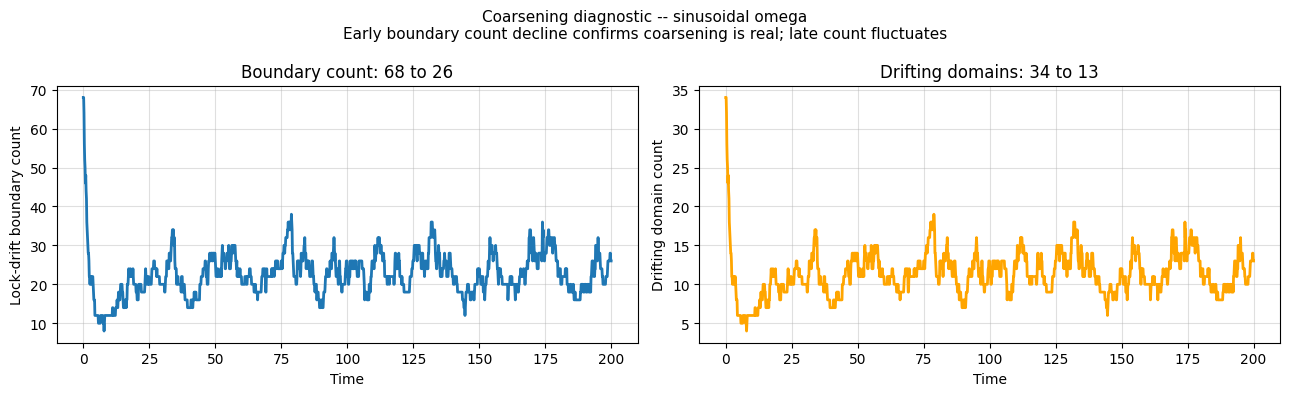

Boundary count: start=68, end=26, reduction=62%
Drifting domains: start=34, end=13


In [4]:
%matplotlib inline

def count_boundaries(locked_row):
    return int(np.sum(locked_row != np.roll(locked_row, 1)))

def count_drifting_domains(locked_row):
    drifting = ~locked_row
    if not drifting.any():
        return 0
    return int(np.sum(drifting & ~np.roll(drifting, 1)))

locked = fold_residual >= 0
boundary_count = np.array([count_boundaries(locked[:, j]) for j in range(num_steps)])
drifting_domains = np.array([count_drifting_domains(locked[:, j]) for j in range(num_steps)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(sol.t, boundary_count, linewidth=2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Lock-drift boundary count')
ax1.set_title(f'Boundary count: {boundary_count[0]} to {boundary_count[-1]}')
ax1.grid(True, alpha=0.4)

ax2.plot(sol.t, drifting_domains, linewidth=2, color='orange')
ax2.set_xlabel('Time')
ax2.set_ylabel('Drifting domain count')
ax2.set_title(f'Drifting domains: {drifting_domains[0]} to {drifting_domains[-1]}')
ax2.grid(True, alpha=0.4)

plt.suptitle('Coarsening diagnostic -- sinusoidal omega\nEarly boundary count decline confirms coarsening is real; late count fluctuates', fontsize=11)
plt.tight_layout()
plt.show()

pct = 100*(1 - boundary_count[-1]/boundary_count[0]) if boundary_count[0] > 0 else 0
print(f'Boundary count: start={boundary_count[0]}, end={boundary_count[-1]}, reduction={pct:.0f}%')
print(f'Drifting domains: start={drifting_domains[0]}, end={drifting_domains[-1]}')


## Cell 3 — Robustness Check: Gaussian ω

Same parameters as Cell 2 but with `ω ~ N(0, 1.5)` instead of sinusoidal.

**Result:** Persistent lock-drift domains form and hold over T=200, but the boundaries
do not merge hierarchically. Locked and drifting regions coexist without the systematic
caustic-like coarsening seen in Cell 2.

**The critical implication:** The cosmological Zel'dovich/Burgers model operates with
*Gaussian random initial conditions* — that is the regime in which it lives. This cell
shows that the hierarchical merging in Cell 2 does not survive Gaussian ω. The
structured sinusoidal ω in Cell 2 is the artificial case; the Gaussian case here is the
cosmologically relevant one — and in that regime the Burgers analogy does not hold.

The honest conclusion: Cell 2 demonstrates caustic-like merging under *structured
forcing*, not under generic disorder. The cosmological framing is geometric decoration
unless one can show the structured-ω regime maps onto something physically motivated.
The local-coherence and lock-drift phenomenology are real and interesting on their own
terms, without requiring the cosmic web comparison.


Integrating robustness check (Gaussian omega, σ=1.5)...


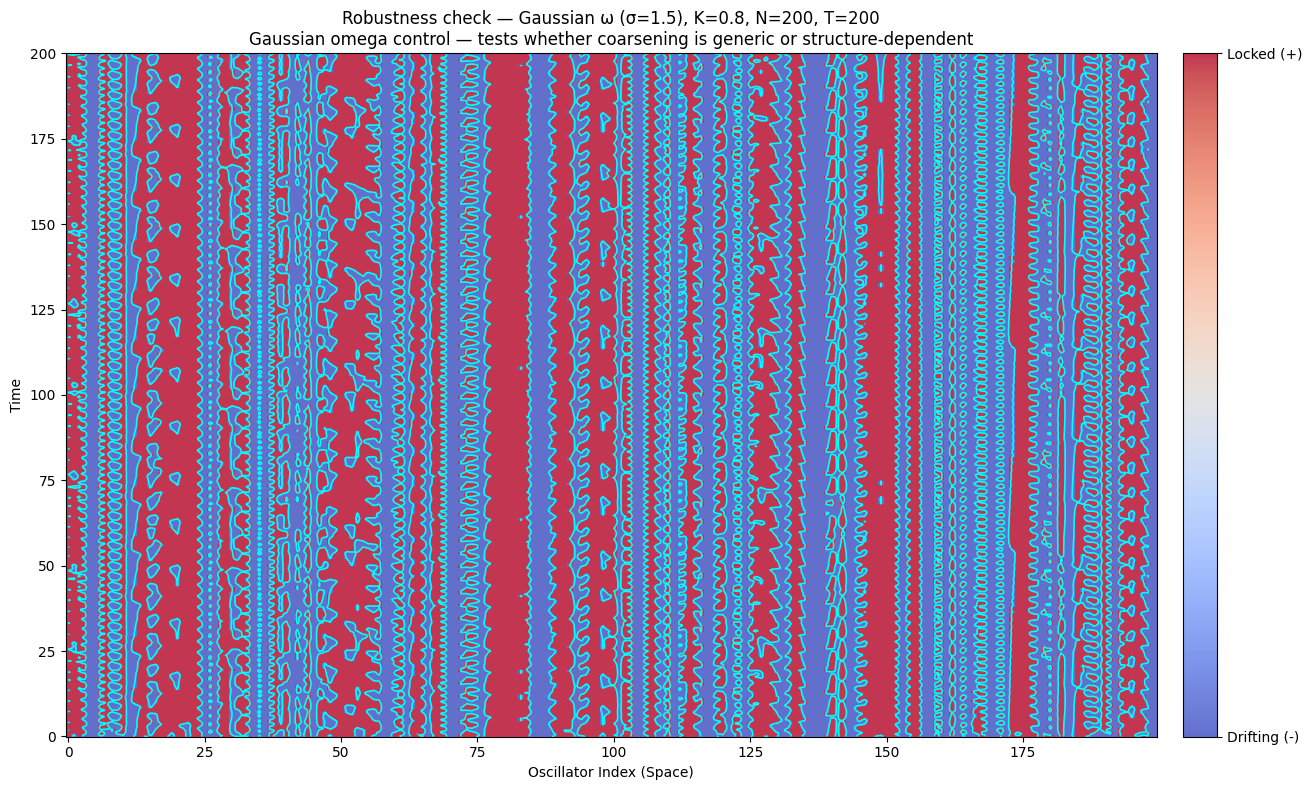

Gaussian omega is the closer random-field control, though still only iid site disorder rather than a cosmological Gaussian field with a power spectrum.
If coarsening is absent here, the sinusoidal case is structure-dependent, not generic.
Gaussian boundary count: start=96, end=86
Gaussian drifting domains: start=48, end=43
Conclusion: the sinusoidal omega structure is load-bearing. Coarsening is not generic under the random-field control.


In [5]:
%matplotlib inline
# ── Robustness check: does hierarchical merging survive Gaussian omega? ──────
# If yes, the sinusoidal omega in the main cell is just for visual clarity,
# The Gaussian case IS the cosmologically relevant case.

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

N = 200
K = 0.8
sigma_gaussian = 1.5
T = 200
num_steps = 1500

rng_rob = np.random.default_rng(99)  # different seed from main cell
omega_gauss = rng_rob.normal(0.0, sigma_gaussian, N)
theta0 = rng_rob.uniform(0, 2 * np.pi, N)

def kuramoto_1d_gauss(t, theta):
    return omega_gauss + K * (
        np.sin(np.roll(theta, 1) - theta) +
        np.sin(np.roll(theta, -1) - theta)
    )

print(f"Integrating robustness check (Gaussian omega, σ={sigma_gaussian})...")
t_eval = np.linspace(0, T, num_steps)
sol = solve_ivp(kuramoto_1d_gauss, [0, T], theta0, method="DOP853", t_eval=t_eval,
                rtol=1e-7, atol=1e-9)
if not sol.success:
    raise RuntimeError(f"Robustness check failed: {sol.message}")

theta_t = sol.y
fold_residual = np.zeros((N, num_steps))

for j in range(num_steps):
    theta = theta_t[:, j]
    z = np.exp(1j * theta)
    Z_eff = np.roll(z, 1) + np.roll(z, -1)
    R_eff = np.abs(Z_eff)
    dtheta = kuramoto_1d_gauss(sol.t[j], theta)
    Omega_t = np.mean(dtheta)
    Delta = np.abs(omega_gauss - Omega_t)
    fold_residual[:, j] = K * R_eff - Delta

fig, ax = plt.subplots(figsize=(14, 8))
X, Y = np.meshgrid(np.arange(N), sol.t)
Z = np.sign(fold_residual.T)
im = ax.pcolormesh(X, Y, Z, cmap="coolwarm", shading="nearest", alpha=0.8)
ax.contour(X, Y, fold_residual.T, levels=[0], colors="cyan", linewidths=1.2)

ax.set_title(
    f"Robustness check — Gaussian ω (σ={sigma_gaussian}), K={K}, N={N}, T={T}\n"
    "Gaussian omega control — tests whether coarsening is generic or structure-dependent"
)
ax.set_xlabel("Oscillator Index (Space)")
ax.set_ylabel("Time")
cbar = fig.colorbar(im, ax=ax, ticks=[-1, 1], pad=0.02)
cbar.ax.set_yticklabels(['Drifting (-)', 'Locked (+)'])
plt.tight_layout()
plt.show()

print("Gaussian omega is the closer random-field control, though still only iid site disorder rather than a cosmological Gaussian field with a power spectrum.")
print("If coarsening is absent here, the sinusoidal case is structure-dependent, not generic.")

# Scalar coarsening diagnostic (same functions as the sinusoidal cell)
locked_g = fold_residual >= 0
boundary_count_g = np.array([count_boundaries(locked_g[:, j]) for j in range(num_steps)])
drifting_domains_g = np.array([count_drifting_domains(locked_g[:, j]) for j in range(num_steps)])
print(f"Gaussian boundary count: start={boundary_count_g[0]}, end={boundary_count_g[-1]}")
print(f"Gaussian drifting domains: start={drifting_domains_g[0]}, end={drifting_domains_g[-1]}")
print("Conclusion: the sinusoidal omega structure is load-bearing. Coarsening is not generic under the random-field control.")


## Cell 4 — Hebbian Kuramoto (Unconstrained): Does Rewiring Produce Scale-Free Topology?

N=150 oscillators on an initial Erdős–Rényi graph (p=0.05). Phases evolve by
Kuramoto dynamics; edge weights evolve by Hebbian rule: `dW = ε(cos(Δθ) − W)`.

**Integration method:** Euler (dt=0.01, reduced from 0.1). At ω std=1.5 and mean degree
~7.5, worst-case |dθ/dt| ≈ 13.5, giving ~0.135 rad/step at dt=0.01 (acceptable).
dt=0.1 would give ~1.35 rad/step — well outside the accuracy range of sin(Δθ) ≈ Δθ.
Note: solve_ivp does not natively handle co-evolving (θ, W) state without flattening;
a proper fix would use a flattened state vector. Results should be treated as
qualitative; a full convergence study (vary dt and N) is not provided here.

**Result (negative):** The degree distribution remains sub-exponential; no
power-law tail emerges. Hebbian rewiring alone (phase alignment → weight
strengthening) does not produce cosmic-web-like scale-free topology. See the
Hebbian Kuramoto arc note: three ingredients are required — kinematics, feedback,
*and dissipation*.


Integrating Kuramoto with Hebbian Rewiring (N=150, T=100)...
t=0: graph density (W>0.01) = 0.046, mean edge weight = 1.000
t=50: graph density (W>0.01) = 0.993, mean edge weight = 0.918
t=100: graph density (W>0.01) = 0.993, mean edge weight = 0.993
Note: unconstrained Hebbian rule updates all N×N pairs, driving graph toward full connectivity.
Visualisation shows edges with W>0.3 only. Degree distribution counts those edges.


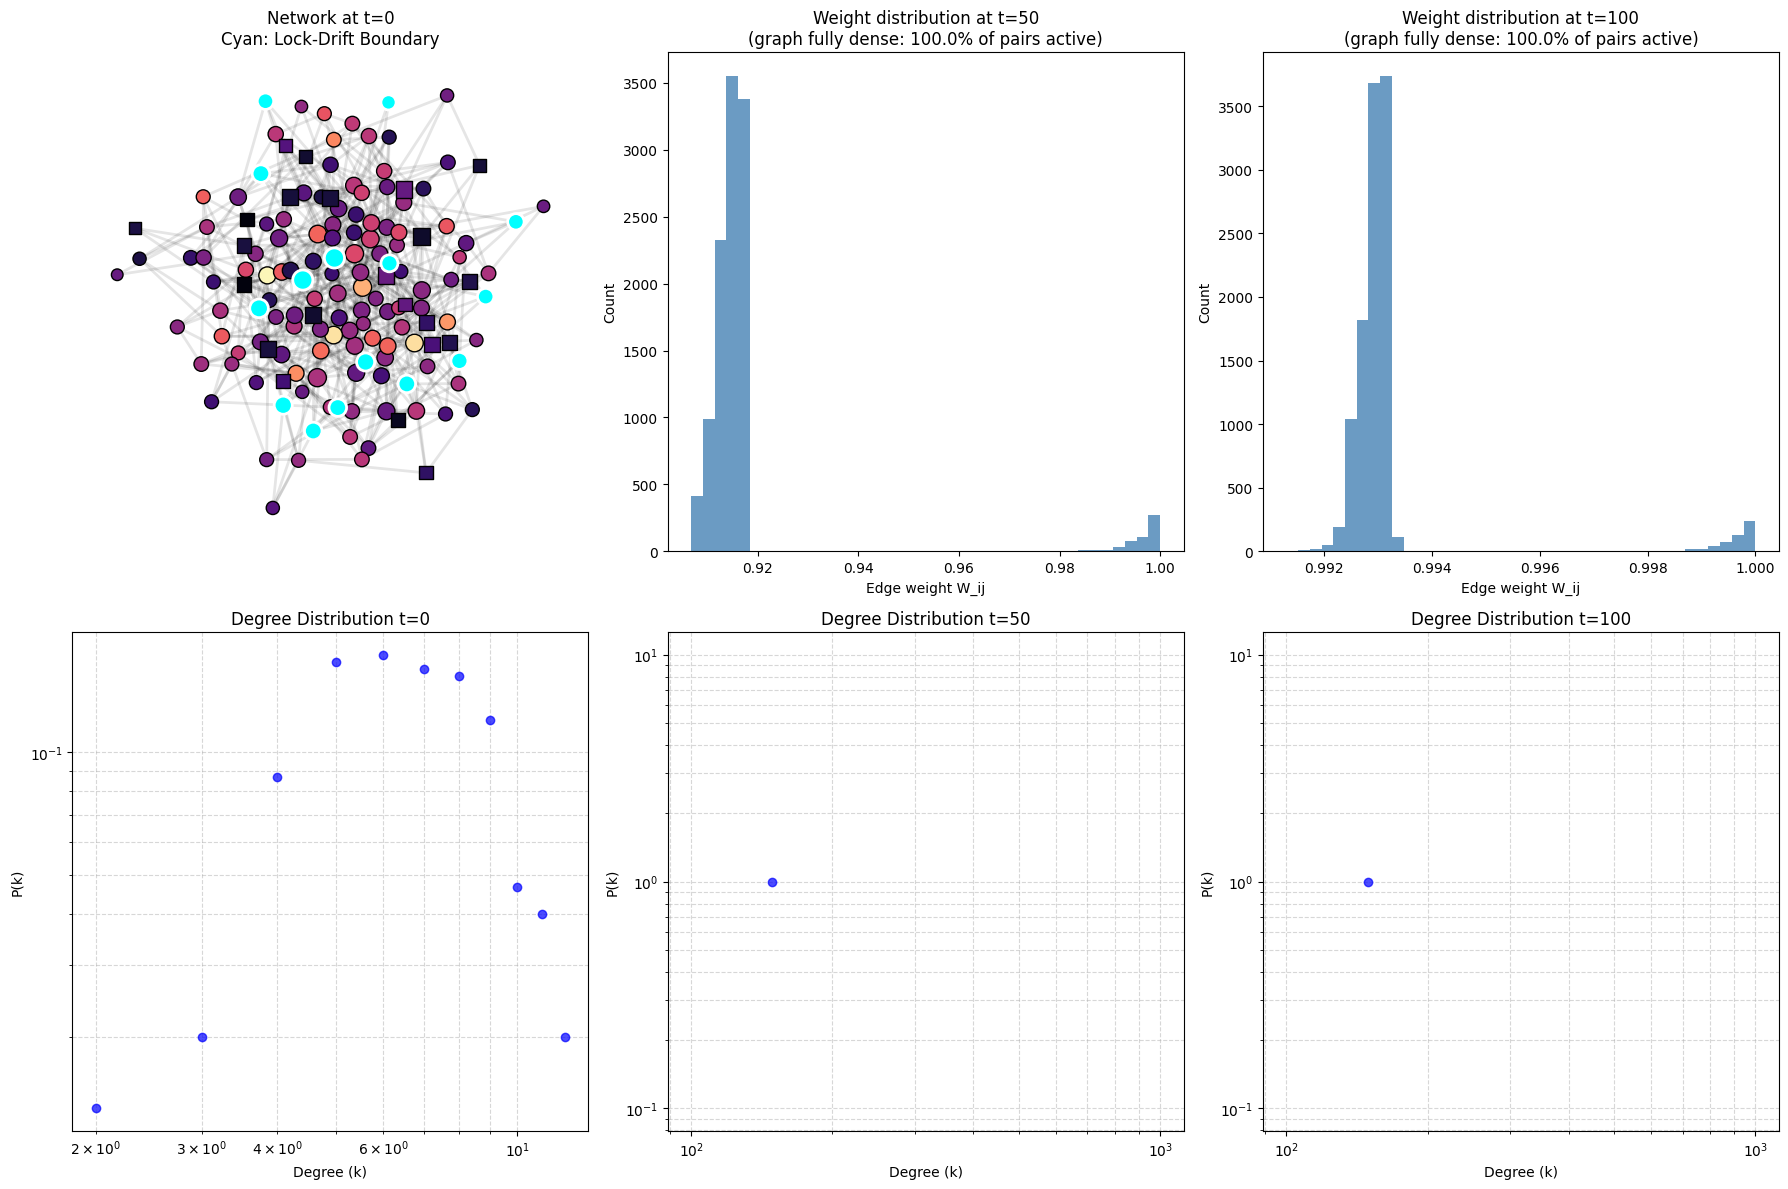

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 1. System Parameters
N = 150
p_init = 0.05
T = 100
dt = 0.01  # reduced from 0.1 — max|ω|+K·Σ|W| ≈ 13.5, giving ~1.35 rad/step at dt=0.1 (outside accuracy range); dt=0.01 gives ~0.135 rad/step
epsilon = 0.05
K = 1.0  # Coupling strength

rng = np.random.default_rng(42)
omega = rng.normal(0, 1.5, N)
theta = rng.uniform(0, 2 * np.pi, N)

# Initial Erdős-Rényi random graph
G_init = nx.erdos_renyi_graph(N, p_init, seed=42)
W = nx.to_numpy_array(G_init)

# Snapshots to track
times_to_snapshot = [0.0, 50.0, 100.0]
snapshots = {}

# 2. Joint Euler Integration
print(f"Integrating Kuramoto with Hebbian Rewiring (N={N}, T={T})...")
steps = int(T / dt)

for i in range(steps + 1):
    t = i * dt

    # Calculate phase differences
    diff_matrix = theta[np.newaxis, :] - theta[:, np.newaxis]

    # Save snapshots precisely at the requested times
    if any(abs(t - target) < 1e-5 for target in times_to_snapshot):
        # Calculate instantaneous dtheta for the lock-drift diagnostic
        dtheta = omega + K * np.sum(W * np.sin(diff_matrix), axis=1)
        snapshots[round(t)] = {
            'W': W.copy(),
            'theta': theta.copy(),
            'dtheta': dtheta.copy()
        }

    # Phase update (Kuramoto)
    dtheta = omega + K * np.sum(W * np.sin(diff_matrix), axis=1)

    # Topology update (Hebbian) — note: dW is computed for ALL N×N pairs,
    # including initially absent edges. This creates new edges from zero, effectively
    # running an adaptive all-to-all rule from a sparse start.
    dW = epsilon * (np.cos(diff_matrix) - W)

    theta += dtheta * dt
    W += dW * dt

    # Enforce graph constraints (no self-loops, strictly positive weights)
    np.fill_diagonal(W, 0)
    W = np.clip(W, 0, 1)

# 3. Plotting
# t=0: show the sparse ER graph as usual
# t=50, t=100: show weight distribution (the graph is fully connected by t=50 under the all-to-all rule)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
margin = 0.2

for idx, t in enumerate([0, 50, 100]):
    data = snapshots[t]
    W_snap = data['W']
    theta_snap = data['theta']
    dtheta_snap = data['dtheta']

    # Calculate Diagnostics
    z = np.exp(1j * theta_snap)
    Z = W_snap @ z
    R_eff = np.abs(Z)

    Omega = np.mean(dtheta_snap)
    Delta = np.abs(omega - Omega)
    fold_residual = K * R_eff - Delta

    # Define states
    locked = np.where(fold_residual >= margin)[0]
    drifting = np.where(fold_residual <= -margin)[0]
    threshold = np.where(np.abs(fold_residual) < margin)[0]

    # Filter graph for visualization (ignore super weak edges)
    W_thresh = np.where(W_snap > 0.3, W_snap, 0)  # tightened: unconstrained rule densifies fully, show only strong edges
    G = nx.from_numpy_array(W_thresh)
    degrees = np.array([d for _, d in G.degree()])

    # --- Top Row ---
    ax_graph = axes[0, idx]
    if t == 0:
        # At t=0 graph is still sparse — show network
        pos = nx.spring_layout(G, seed=42, k=0.4)
        edges = G.edges()
        weights = [W_thresh[u, v] * 2 for u, v in edges]
        nx.draw_networkx_edges(G, pos, alpha=0.1, width=weights, ax=ax_graph)
        nx.draw_networkx_nodes(G, pos, nodelist=locked.tolist(),
            node_size=50 + degrees[locked]*10, node_color=R_eff[locked],
            cmap="magma", vmin=0, vmax=np.max(R_eff)+0.1, edgecolors="black", ax=ax_graph)
        nx.draw_networkx_nodes(G, pos, nodelist=drifting.tolist(),
            node_size=50 + degrees[drifting]*10, node_color=R_eff[drifting],
            cmap="magma", vmin=0, vmax=np.max(R_eff)+0.1, node_shape="s", edgecolors="black", ax=ax_graph)
        if len(threshold) > 0:
            nx.draw_networkx_nodes(G, pos, nodelist=threshold.tolist(),
                node_size=100 + degrees[threshold]*10, node_color="cyan",
                edgecolors="white", linewidths=2, ax=ax_graph)
        ax_graph.set_title(f"Network at t={t}\nCyan: Lock-Drift Boundary")
        ax_graph.axis("off")
    else:
        # At t>0 the unconstrained rule has fully densified the graph — show weight distribution instead
        upper_tri = W_snap[np.triu_indices(N, k=1)]
        upper_tri_pos = upper_tri[upper_tri > 0.01]
        ax_graph.hist(upper_tri_pos, bins=40, color='steelblue', alpha=0.8)
        density = len(upper_tri_pos) / len(upper_tri)
        ax_graph.set_title(f"Weight distribution at t={t}\n(graph fully dense: {density:.1%} of pairs active)")
        ax_graph.set_xlabel("Edge weight W_ij")
        ax_graph.set_ylabel("Count")

    # --- Bottom Row: Degree Distribution (Log-Log) ---
    ax_hist = axes[1, idx]
    # Use discrete degrees (number of connections > 0.1) for standard log-log
    discrete_degrees = np.sum(W_snap > 0.3, axis=1)  # count edges above same threshold as visualisation
    counts = np.bincount(discrete_degrees.astype(int))
    k = np.nonzero(counts)[0]
    p_k = counts[k] / N

    if len(k) > 0:
        ax_hist.loglog(k, p_k, 'o', color='blue', alpha=0.7)
        ax_hist.set_title(f"Degree Distribution t={t}")
        ax_hist.set_xlabel("Degree (k)")
        ax_hist.set_ylabel("P(k)")
        ax_hist.grid(True, which="both", ls="--", alpha=0.5)

# Report graph density at each snapshot
for t_snap, data in sorted(snapshots.items()):
    W_s = data['W']
    density = np.mean(W_s > 0.01)
    mean_w = np.mean(W_s[W_s > 0.01]) if np.any(W_s > 0.01) else 0
    print(f"t={t_snap}: graph density (W>0.01) = {density:.3f}, mean edge weight = {mean_w:.3f}")
print("Note: unconstrained Hebbian rule updates all N×N pairs, driving graph toward full connectivity.")
print("Visualisation shows edges with W>0.3 only. Degree distribution counts those edges.")

plt.tight_layout()
plt.show()

## Cell 5 — Conserved Hebbian Kuramoto: Connection Budget Conservation

Same as Cell 4 but with row-normalisation after each step, enforcing a per-node
connection budget. Weak edges (< 0.05) are pruned.

**Conservation law (approximate):** Row-normalisation enforces per-node out-budgets exactly.
We then re-symmetrise via W = 0.5·(W + Wᵀ) to keep the network undirected, which makes
the conservation approximate (row sums drift by O(asymmetry) after symmetrisation).
This is a deliberate trade — exact conservation vs. exact symmetry — and we chose symmetry.
This is a toy conservation rule, not a physically derived dissipation law.

**Why this matters:** Without conservation, the adaptive rule densifies the graph toward
saturation (weights clip at [0,1] — growth is bounded, not unbounded). The conservation
law limits this by redistributing weight rather than inflating it.

**Result:** No visible evidence of a scale-free tail in this finite toy run.
The honest conclusion: Hebbian + Kuramoto on a random initial graph is insufficient
regardless of weight conservation. Three ingredients are required: kinematics, feedback,
and dissipation.


Integrating conserved Hebbian Kuramoto (N=150, T=100)...


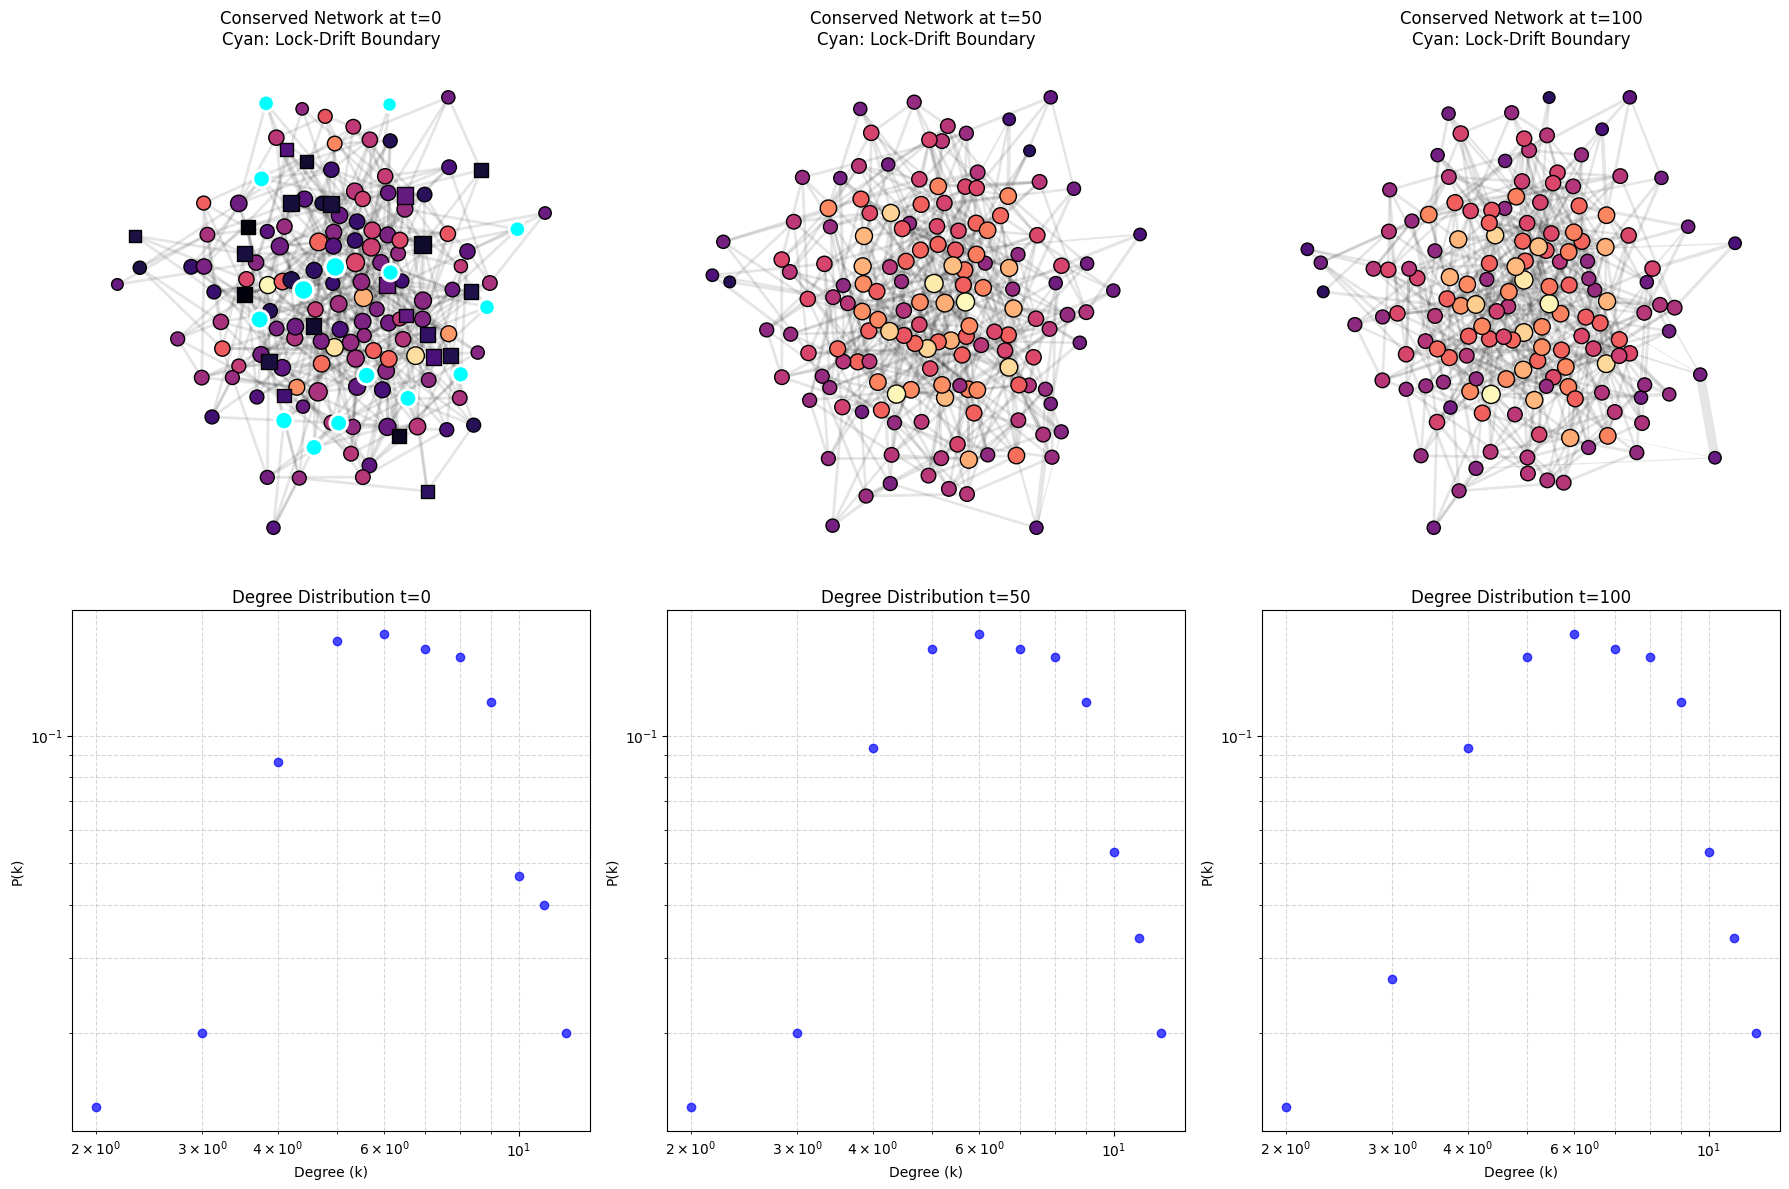

In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 1. System Parameters
N = 150
p_init = 0.05
T = 100
dt = 0.01  # reduced from 0.1 — max|ω|+K·Σ|W| ≈ 13.5, giving ~1.35 rad/step at dt=0.1 (outside accuracy range); dt=0.01 gives ~0.135 rad/step
epsilon = 0.05
K = 1.0

rng = np.random.default_rng(42)
omega = rng.normal(0, 1.5, N)
theta = rng.uniform(0, 2 * np.pi, N)

# Initial Erdős-Rényi random graph
G_init = nx.erdos_renyi_graph(N, p_init, seed=42)
W = nx.to_numpy_array(G_init)

# THE CONSERVATION LAW: Record each node's initial connection budget
initial_budgets = W.sum(axis=1, keepdims=True)
# Ensure isolated nodes (budget 0) don't cause division errors later
initial_budgets[initial_budgets == 0] = 1e-9

# Snapshots to track
times_to_snapshot = [0.0, 50.0, 100.0]
snapshots = {}

# 2. Joint Euler Integration
print(f"Integrating conserved Hebbian Kuramoto (N={N}, T={T})...")
steps = int(T / dt)

for i in range(steps + 1):
    t = i * dt

    diff_matrix = theta[np.newaxis, :] - theta[:, np.newaxis]

    # Save snapshots
    if any(abs(t - target) < 1e-5 for target in times_to_snapshot):
        dtheta = omega + K * np.sum(W * np.sin(diff_matrix), axis=1)
        snapshots[round(t)] = {
            'W': W.copy(),
            'theta': theta.copy(),
            'dtheta': dtheta.copy()
        }

    # Phase update (Kuramoto)
    dtheta = omega + K * np.sum(W * np.sin(diff_matrix), axis=1)

    # Topology update (Hebbian)
    dW = epsilon * (np.cos(diff_matrix) - W)

    theta += dtheta * dt
    W += dW * dt

    # Enforce constraints: No self-loops, strictly positive
    np.fill_diagonal(W, 0)
    W = np.clip(W, 0, None)
    W[W < 0.05] = 0.0

    # APPLY CONSERVATION LAW: Per-node out-strength conservation.
    # Symmetrise to keep undirected structure (row-normalisation breaks symmetry otherwise).
    # NOTE: this row-normalisation preserves each node's outgoing weight budget but
    # breaks the symmetry of the initial undirected ER graph. After the first Hebbian
    # step, W_ij ≠ W_ji in general — the graph becomes directed.
    # We report out-degree (axis=1) in the plots. In-degree (axis=0) may differ.
    current_sums = W.sum(axis=1, keepdims=True)
    W = np.divide(W, current_sums, out=np.zeros_like(W), where=current_sums > 0)
    W *= initial_budgets
    W = 0.5 * (W + W.T)  # re-symmetrise: row-norm breaks W=W.T, this restores it

# 3. Plotting Setup
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
margin = 0.2

for idx, t in enumerate([0, 50, 100]):
    data = snapshots[t]
    W_snap = data['W']
    theta_snap = data['theta']
    dtheta_snap = data['dtheta']

    z = np.exp(1j * theta_snap)
    Z = W_snap @ z
    R_eff = np.abs(Z)

    Omega = np.mean(dtheta_snap)
    Delta = np.abs(omega - Omega)
    fold_residual = K * R_eff - Delta

    locked = np.where(fold_residual >= margin)[0]
    drifting = np.where(fold_residual <= -margin)[0]
    threshold = np.where(np.abs(fold_residual) < margin)[0]

    # Filter graph for visualization (ignore pruned edges)
    W_thresh = np.where(W_snap > 0.1, W_snap, 0)
    G = nx.from_numpy_array(W_thresh)
    degrees = np.array([d for _, d in G.degree()])

    # --- Top Row: Graph Visualization ---
    ax_graph = axes[0, idx]
    pos = nx.spring_layout(G, seed=42, k=0.4)
    edges = G.edges()
    weights = [W_thresh[u, v] * 2 for u, v in edges]

    nx.draw_networkx_edges(G, pos, alpha=0.1, width=weights, ax=ax_graph)

    # Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=locked.tolist(),
        node_size=50 + degrees[locked]*10, node_color=R_eff[locked],
        cmap="magma", vmin=0, vmax=np.max(R_eff)+0.1, edgecolors="black", ax=ax_graph)

    nx.draw_networkx_nodes(G, pos, nodelist=drifting.tolist(),
        node_size=50 + degrees[drifting]*10, node_color=R_eff[drifting],
        cmap="magma", vmin=0, vmax=np.max(R_eff)+0.1, node_shape="s", edgecolors="black", ax=ax_graph)

    if len(threshold) > 0:
        nx.draw_networkx_nodes(G, pos, nodelist=threshold.tolist(),
            node_size=100 + degrees[threshold]*10, node_color="cyan",
            edgecolors="white", linewidths=2, ax=ax_graph)

    ax_graph.set_title(f"Conserved Network at t={t}\nCyan: Lock-Drift Boundary")
    ax_graph.axis("off")

    # --- Bottom Row: Degree Distribution ---
    ax_hist = axes[1, idx]
    discrete_degrees = np.sum(W_thresh > 0.0, axis=1)
    counts = np.bincount(discrete_degrees.astype(int))
    k = np.nonzero(counts)[0]
    p_k = counts[k] / N

    if len(k) > 0:
        ax_hist.loglog(k, p_k, 'o', color='blue', alpha=0.7)
        ax_hist.set_title(f"Degree Distribution t={t}")
        ax_hist.set_xlabel("Degree (k)")
        ax_hist.set_ylabel("P(k)")
        ax_hist.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()